In [11]:
from napari_ai_lab.models.image_data_model import ImageDataModel

data_model = ImageDataModel("data/bees")
print(data_model)


ImageDataModel(C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees, 7 images)


In [14]:
from napari_ai_lab.Segmenters.GlobalSegmenters.Cellpose3SkopSegmenter import Cellpose3SkopSegmenter

segmenter = Cellpose3SkopSegmenter()
segmenter.model_save_dir = str(data_model.get_models_directory())
print(list(segmenter.get_model_axis_map()))


['cyto3', 'nuclei', 'bacteria_phase', 'bacteria_fluorescence', 'yeast_phase', 'yeast_brightfield', 'tissue', 'live_cell', 'deepbacs', 'bees_cellpose3_2026-09-17_1046']


In [ ]:
MODEL = "bees_cellpose3_2026-09-17_1046"
assert MODEL in segmenter.get_model_axis_map(), MODEL
segmenter.set_model(MODEL)


In [17]:
# collapse C or the slicer iterates Y, one cellpose call per row
processor = data_model.segment_sequence(
    segmenter, segmenter.get_recommended_axis(), axes_to_collapse=["C"]
)
print(processor.summary())


Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_01.png
Loaded image shape: (1371, 2048, 3)
Axis types: YXC
Scale (per axis): [1.0, 1.0]
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_02.png
Loaded image shape: (1536, 2048, 3)
Axis types: YXC
Scale (per axis): [1.0, 1.0]
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_03.png
Loaded image shape: (1371, 2048, 3)
Axis types: YXC
Scale (per axis): [1.0, 1.0]
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_04.png
Loaded image shape: (1229, 2048, 3)
Axis types: YXC
Scale (per axis): [1.0, 1.0]
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_05.png
Loaded image shape: (1037, 1843, 3)
Axis types: YXC
Scale (per axis): [1.0, 1.0]
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_06.png
Loaded image shape: (996, 1761, 3)
Axis typ

Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_01.png
Loaded image shape: (1371, 2048, 3)
Axis types: YXC
Scale (per axis): [1.0, 1.0]
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_02.png
Loaded image shape: (1536, 2048, 3)
Axis types: YXC
Scale (per axis): [1.0, 1.0]
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_03.png
Loaded image shape: (1371, 2048, 3)
Axis types: YXC
Scale (per axis): [1.0, 1.0]
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_04.png
Loaded image shape: (1229, 2048, 3)
Axis types: YXC
Scale (per axis): [1.0, 1.0]
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_05.png
Loaded image shape: (1037, 1843, 3)
Axis types: YXC
Scale (per axis): [1.0, 1.0]
Loading image: C:\Users\bnort\work\ImageJ2022\tnia\i2k-2026\notebooks\data\bees\comb_06.png
Loaded image shape: (996, 1761, 3)
Axis typ

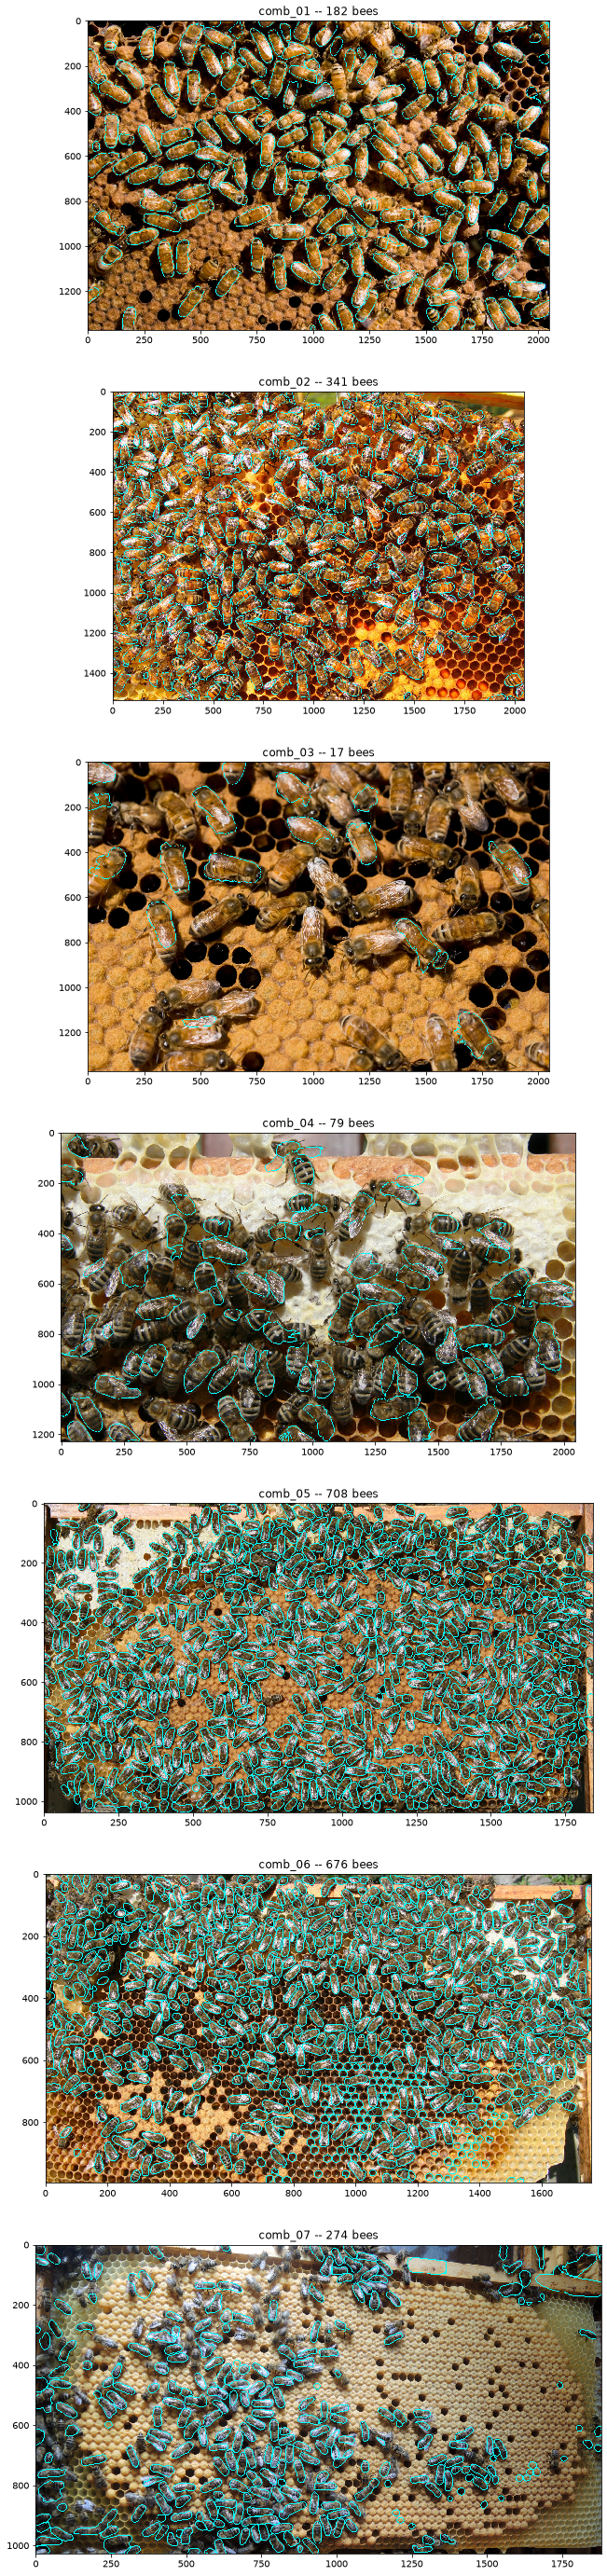

In [19]:
from tnia.plotting.plt_helper import imshow_multi2d, mask_outline_overlay

overlays, titles = [], []
for i, path in enumerate(data_model.get_image_paths()):
    image = data_model.load_image(i)
    mask = data_model.load_existing_predictions(i)
    overlays.append(mask_outline_overlay(image, mask))
    titles.append(f"{path.stem} -- {mask.max()} bees")

fig = imshow_multi2d(overlays, titles, len(overlays), 1, width=13, height=7 * len(overlays))
